## Assignment Task: Path Interpolation and Visualization

In this exercise, you are provided with a CSV file named `loop_track_waypoints.csv`, which contains a sequence of indexed 2D waypoints that form a closed-loop track. Your task is to interpolate these waypoints to generate a smooth continuous path and visualize the resulting curve.

### Dataset Description

The CSV file contains the following columns:

- `Index`: An integer representing the order of the waypoint.
- `x`: The x-coordinate of the waypoint (in meters).
- `y`: The y-coordinate of the waypoint (in meters).

The track is closed, i.e., the final waypoint coincides with the starting point to form a loop.

### Objectives

1. **Read** the CSV file using an appropriate data processing library such as `pandas`.
2. **Perform interpolation** over the waypoints using a method of your choice (e.g., `scipy.interpolate` or spline interpolation).
3. **Visualize** both the original discrete waypoints and the resulting smooth curve on the same plot for comparison.
4. Ensure the interpolated path **preserves the closed-loop nature** of the track.

### Recommended Libraries

You may use the following libraries:
- `pandas` for reading the CSV file.
- `matplotlib` or `plotly` for visualization.
- `scipy.interpolate` (e.g., `splprep` and `splev`) or `interp1d` for interpolation.

### 📌 Instructions

- Ensure that the file `loop_track_waypoints.csv` is placed in the **same directory** as this notebook.
- Label your axes and add a legend to your plot.
- Comment your code appropriately to explain the logic and steps used.
- Try using both linear and spline-based interpolation methods if time permits.


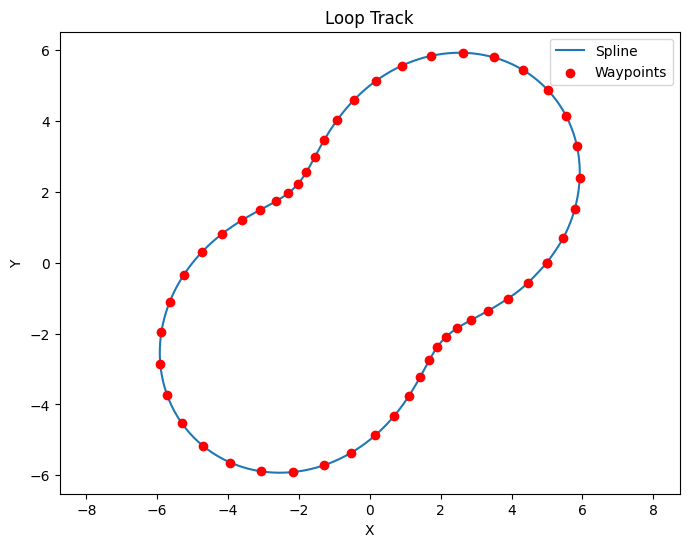

In [2]:
import pandas as pd
import numpy as np
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt

df=pd.read_csv("loop_track_waypoints.csv")

x=df['X'].values
y=df['Y'].values
t=np.arange(len(x)) #creates an array of indices 0,1,2... so that we interpolate by that since x in non increasing

# Closing the loop
x_closed=np.append(x,x[0]) # append to close the loop
y_closed=np.append(y,y[0])
t_closed=np.append(t,t[-1]+1) # to make length of x_closed and t_closed same otherwise scipy throws error

# interpolate
cs_x=CubicSpline(t_closed,x_closed,bc_type="natural") # fits x using t via cubic spline interpolation
cs_y=CubicSpline(t_closed,y_closed,bc_type="natural")

# Fine-grained t for smooth curve
t_fine = np.linspace(t_closed[0], t_closed[-1], 500) # create 500 evenly spaces t values in full range

x_fine = cs_x(t_fine) # evaluate x at each of the 500 points
y_fine = cs_y(t_fine)

plt.figure(figsize=(8, 6))
plt.plot(x_fine, y_fine, label='Spline') # plots the graph
plt.scatter(x, y, color='red', zorder=5, label='Waypoints') # adds the point
plt.axis('equal')       # important for tracks so it doesn't look squished
plt.legend()
plt.title('Loop Track')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()